<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

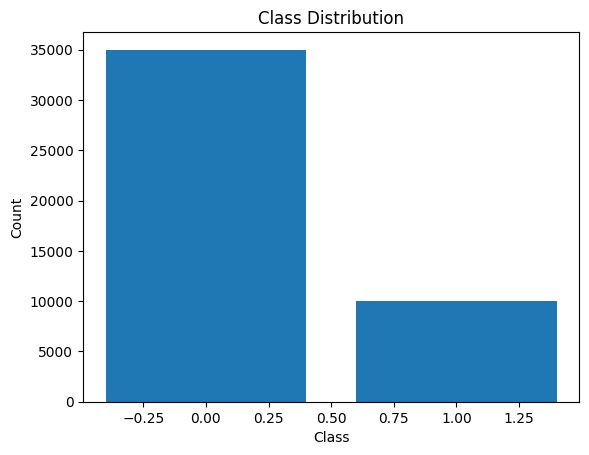

Training Accuracy: 1.0000
Testing Accuracy: 0.8739
Model saved successfully!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
import joblib

# ==========================
# LOAD DATA
# ==========================
df = pd.read_csv('loan_data.csv')

# ==========================
# DATA EXPLORATION
# ==========================
print(df.info())
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Missing values:\n{df.isnull().sum()}")

# ==========================
# ENCODING DICTIONARIES
# ==========================
loan_intent_dct = {
    'PERSONAL': 1, 'EDUCATION': 2, 'MEDICAL': 3,
    'VENTURE': 4, 'HOMEIMPROVEMENT': 5, 'DEBTCONSOLIDATION': 6
}

person_gender_dict = {'female': 1, 'male': 0}

person_edu = {
    'Master': 1, 'High School': 2, 'Bachelor': 3, 
    'Associate': 4, 'Doctorate': 5
}

person_home_ownership_dict = {
    'RENT': 1, 'OWN': 2, 'MORTGAGE': 3, 'OTHER': 4
}

previous_loan_defaults_on_file_dct = {'No': 1, 'Yes': 2}

# ==========================
# DATA PREPROCESSING
# ==========================
df['loan_intent'] = df['loan_intent'].map(loan_intent_dct)
df['person_gender'] = df['person_gender'].map(person_gender_dict)
df['person_education'] = df['person_education'].map(person_edu)
df['person_home_ownership'] = df['person_home_ownership'].map(person_home_ownership_dict)
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map(previous_loan_defaults_on_file_dct)

# ==========================
# CLASS DISTRIBUTION
# ==========================
loan_value_count = df['loan_status'].value_counts()
plt.bar(loan_value_count.index, loan_value_count.values)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

# ==========================
# TRAIN-TEST SPLIT
# ==========================
x = df.drop('loan_status', axis=1)
y = df['loan_status']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, stratify=y, random_state=42
)

# ==========================
# HANDLE CLASS IMBALANCE (SMOTE)
# ==========================
sm = SMOTE(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

# ==========================
# MODEL TRAINING
# ==========================
model = DecisionTreeClassifier(criterion="gini", random_state=42)
model.fit(x_train_res, y_train_res)

# ==========================
# MODEL EVALUATION
# ==========================
train_accuracy = model.score(x_train_res, y_train_res)
test_accuracy = model.score(x_test, y_test)

print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

# ==========================
# SAVE MODEL
# ==========================
joblib.dump(model, 'loan_aprovel_model')
print("Model saved successfully!")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, SVR

In [3]:
df=pd.read_csv('loan_data.csv')

In [4]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [6]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='str')

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [9]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [10]:
df['loan_intent'].unique()


<StringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

In [11]:
loan_intent_dct={
    'PERSONAL':1,         'EDUCATION':2,           'MEDICAL':3,
           'VENTURE':4,   'HOMEIMPROVEMENT':5, 'DEBTCONSOLIDATION':6
}
df['loan_intent']=df['loan_intent'].map(loan_intent_dct)

In [12]:
df['person_gender'].unique()

<StringArray>
['female', 'male']
Length: 2, dtype: str

In [13]:
person_gender_dict={
    'female':1, 'male':0
}
df['person_gender']=df['person_gender'].map(person_gender_dict)

In [14]:
df['person_education'].unique()


<StringArray>
['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
Length: 5, dtype: str

In [15]:
person_edu={
    'Master':1, 'High School':2, 'Bachelor':3, 'Associate':4, 'Doctorate':5

}
df['person_education']=df['person_education'].map(person_edu)

In [16]:
df['person_home_ownership'].unique()

<StringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str

In [17]:
person_home_ownership_dict={
    'RENT':1, 'OWN':2, 'MORTGAGE':3, 'OTHER':4
}
df['person_home_ownership']=df['person_home_ownership'].map(person_home_ownership_dict)

In [18]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,1,1,71948.0,0,1,35000.0,1,16.02,0.49,3.0,561,No,1
1,21.0,1,2,12282.0,0,2,1000.0,2,11.14,0.08,2.0,504,Yes,0
2,25.0,1,2,12438.0,3,3,5500.0,3,12.87,0.44,3.0,635,No,1
3,23.0,1,3,79753.0,0,1,35000.0,3,15.23,0.44,2.0,675,No,1
4,24.0,0,1,66135.0,1,1,35000.0,3,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,0,4,47971.0,6,1,15000.0,3,15.66,0.31,3.0,645,No,1
44996,37.0,1,4,65800.0,17,1,9000.0,5,14.07,0.14,11.0,621,No,1
44997,33.0,0,4,56942.0,7,1,2771.0,6,10.02,0.05,10.0,668,No,1
44998,29.0,0,3,33164.0,4,1,12000.0,2,13.23,0.36,6.0,604,No,1


In [19]:
df['previous_loan_defaults_on_file'].unique()

<StringArray>
['No', 'Yes']
Length: 2, dtype: str

In [20]:
previous_loan_defaults_on_file_dct={
    'No':1, 'Yes':2
}
df['previous_loan_defaults_on_file']=df['previous_loan_defaults_on_file'].map(previous_loan_defaults_on_file_dct)

In [21]:
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,1,1,71948.0,0,1,35000.0,1,16.02,0.49,3.0,561,1,1
1,21.0,1,2,12282.0,0,2,1000.0,2,11.14,0.08,2.0,504,2,0
2,25.0,1,2,12438.0,3,3,5500.0,3,12.87,0.44,3.0,635,1,1
3,23.0,1,3,79753.0,0,1,35000.0,3,15.23,0.44,2.0,675,1,1
4,24.0,0,1,66135.0,1,1,35000.0,3,14.27,0.53,4.0,586,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,0,4,47971.0,6,1,15000.0,3,15.66,0.31,3.0,645,1,1
44996,37.0,1,4,65800.0,17,1,9000.0,5,14.07,0.14,11.0,621,1,1
44997,33.0,0,4,56942.0,7,1,2771.0,6,10.02,0.05,10.0,668,1,1
44998,29.0,0,3,33164.0,4,1,12000.0,2,13.23,0.36,6.0,604,1,1


In [22]:
x=df.drop('loan_status',axis=1)

In [23]:
y=df['loan_status']

In [24]:
x

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
0,22.0,1,1,71948.0,0,1,35000.0,1,16.02,0.49,3.0,561,1
1,21.0,1,2,12282.0,0,2,1000.0,2,11.14,0.08,2.0,504,2
2,25.0,1,2,12438.0,3,3,5500.0,3,12.87,0.44,3.0,635,1
3,23.0,1,3,79753.0,0,1,35000.0,3,15.23,0.44,2.0,675,1
4,24.0,0,1,66135.0,1,1,35000.0,3,14.27,0.53,4.0,586,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,0,4,47971.0,6,1,15000.0,3,15.66,0.31,3.0,645,1
44996,37.0,1,4,65800.0,17,1,9000.0,5,14.07,0.14,11.0,621,1
44997,33.0,0,4,56942.0,7,1,2771.0,6,10.02,0.05,10.0,668,1
44998,29.0,0,3,33164.0,4,1,12000.0,2,13.23,0.36,6.0,604,1


In [25]:
y

0        1
1        0
2        1
3        1
4        1
        ..
44995    1
44996    1
44997    1
44998    1
44999    1
Name: loan_status, Length: 45000, dtype: int64

In [26]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

In [27]:
#ye line sklearn library se train _test_split function ko import karti hai
#sklearn=machine learning library
#model_selection=model ko select karna prediction ke liye
#train_test_split=data ko split karna train or test ke liye

from sklearn.model_selection import train_test_split

In [28]:
# x_train → Training ke liye input data
# x_test → Testing ke liye input data
# y_train → Training ke liye output (label)
# y_test → Testing ke liye output (label)
#test_size=0.2-> data test hoga 20%
#random_state=42-> data train hoga 80%

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
y_test

37979    0
9911     0
43386    1
13822    0
44810    1
        ..
14572    0
30384    0
36665    0
30569    0
5321     0
Name: loan_status, Length: 9000, dtype: int64

In [30]:
x_train

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file
25180,34.0,1,3,97265.0,11,3,15000.0,1,12.73,0.15,9.0,631,1
12555,25.0,0,2,72953.0,3,1,12000.0,4,11.86,0.16,4.0,659,2
29153,41.0,1,1,322597.0,18,3,24000.0,1,10.37,0.07,11.0,683,2
23838,27.0,0,4,94232.0,4,1,9600.0,2,17.14,0.10,7.0,641,1
35686,27.0,0,1,84873.0,7,1,7059.0,5,12.97,0.08,3.0,706,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,26.0,0,2,88451.0,6,3,10625.0,2,6.03,0.12,4.0,559,2
44732,25.0,1,2,34772.0,3,3,5876.0,5,11.69,0.17,4.0,647,1
38158,33.0,1,4,58317.0,9,3,10707.0,4,10.74,0.18,9.0,652,2
860,26.0,0,1,178602.0,6,1,20000.0,6,17.99,0.11,3.0,604,1


In [31]:
#svc=support vector classification
#svm model banane ke liye
# sv=SVC()

In [32]:
#model ko train karna ke liye training data se

# sv.fit(x_train,y_train)
# 

In [33]:
# model accuracy batata h test data ka
# sv.score(x_test,y_test)

In [34]:
#ye train data ki accurecy batata hai
# sv.score(x_train,y_train)

In [35]:
#x_test ke data ko predict(guess karna) karne ke liye
# pred=sv.predict(x_test)
# pred

In [36]:
# pred[0:20]

In [37]:
# y_test[0:10]

In [38]:
loan_value_count = df['loan_status'].value_counts()

In [39]:
loan_value_count

loan_status
0    35000
1    10000
Name: count, dtype: int64

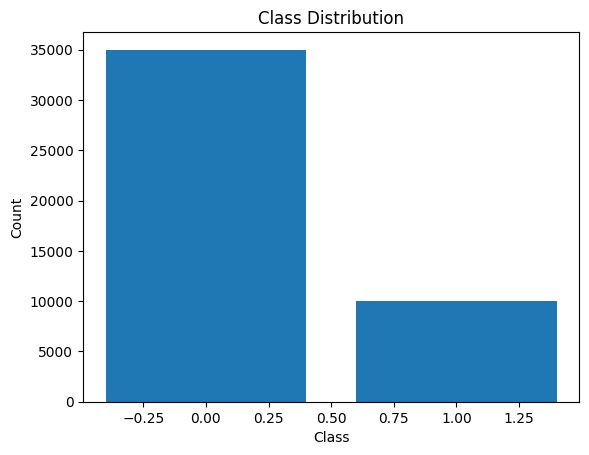

In [40]:
plt.bar(loan_value_count.index, loan_value_count.values)
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Class Distribution')
plt.show()

In [41]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


In [42]:
from imblearn.over_sampling import SMOTE

In [43]:
# Split Frist
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y)

# Apply SMOTE to the training data
sm = SMOTE(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)

# Train Model
# model.fit(x_train_res, y_train_res)

In [44]:
print(y_train_res)

0        0
1        0
2        1
3        0
4        1
        ..
55995    1
55996    1
55997    1
55998    1
55999    1
Name: loan_status, Length: 56000, dtype: int64


In [45]:
train_res_values =y_train_res.value_counts()

<BarContainer object of 2 artists>

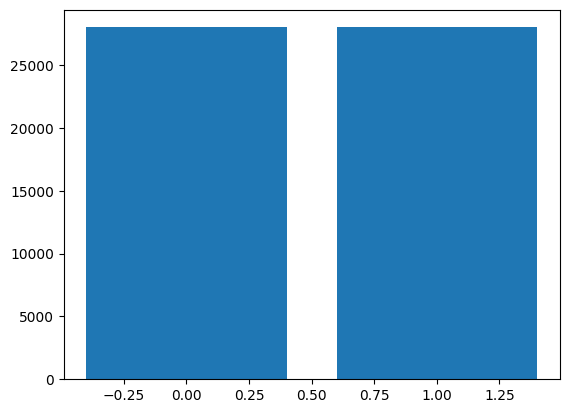

In [46]:
plt.bar(train_res_values.index, train_res_values.values)

In [47]:
from sklearn.tree import DecisionTreeClassifier
sv=DecisionTreeClassifier(criterion="gini")
sv.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [48]:
sv.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [49]:
pred=sv.predict(x_test)
pred

array([0, 1, 0, ..., 0, 0, 0], shape=(9000,))

In [50]:
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
dtr=DecisionTreeClassifier()
dtr.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [51]:
dtr.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [52]:
dtr.score(x_train,y_train)

1.0

In [53]:
dtr.score(x_test,y_test)

0.894

In [54]:
dtr.predict(x_test)

array([0, 1, 0, ..., 0, 0, 0], shape=(9000,))

In [55]:
from sklearn.tree import DecisionTreeClassifier
import joblib
dtr=DecisionTreeRegressor()
dtr.fit(x_train,y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

In [61]:
x.shape 

(45000, 13)

In [56]:
joblib.dump(dtr,'loan_aprovel_model')

['loan_aprovel_model']

In [57]:
model=joblib.load('loan_aprovel_model')

In [58]:
dtr.predict(x_test)

array([0., 1., 0., ..., 0., 0., 0.], shape=(9000,))

In [59]:
y_test

28421    0
17962    1
37161    0
19506    0
34485    0
        ..
31781    0
27479    0
16393    0
23211    0
18412    0
Name: loan_status, Length: 9000, dtype: int64